# Road Accidents Comparison: United States vs United Kingdom

## Introduction
This notebook compares road accident patterns, severity, temporal trends, and contributing factors between the US and UK.

**Objectives:**
- Analyze temporal patterns (year, month, hour, day of week)
- Compare severity distributions
- Explore weather, road conditions, and location factors
- Identify similarities and key differences
- Provide data-driven insights

**Datasets:**
- US: 500,000 sample of US Accidents (2016–2023)
- UK: Official UK Road Casualty Statistics (Last 5 years)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
from urllib.request import urlretrieve
import zipfile
import gdown #requires pip install gdown or conda install conda-forge::gdown


# import geopandas as gpd
# import folium

%matplotlib inline


In [ ]:

# ================== DIRECT LOAD FROM GOV.UK ==================

uk_collision_url = "https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-collision-last-5-years.csv"

print("Downloading UK Collisions data...")
uk_acc = pd.read_csv(uk_collision_url, low_memory=False)
years = uk_acc['collision_year'].unique()
years.sort()

print("UK Collisions Shape:", uk_acc.shape)
print("Columns:", uk_acc.columns.tolist())
print("Years covered:", years)

In [ ]:
# File ID from the official sampled dataset
file_id = "1U3u8QYzLjnEaSurtZfSAS_oh9AT2Mn8X"
url = f"https://drive.google.com/uc?id={file_id}"

output_zip = "US_Accidents_500k.zip"

print("Downloading US Accidents 500k sample using gdown...")
gdown.download(url, output_zip, quiet=False)

print("Download finished. Extracting files...")

In [ ]:
import zipfile

# Extract the zip file
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")
    print("Extracted files:")
    print(os.listdir("."))

# Find the CSV file
csv_files = [f for f in os.listdir(".") if f.endswith('.csv')]
print("CSV files found:", csv_files)

# Load the main CSV
if csv_files:
    csv_name = csv_files[0]
    us_acc = pd.read_csv(csv_name, low_memory=False)
    print(f"✅ Successfully loaded {csv_name}")
    print("Shape:", us_acc.shape)
    print("Years:", sorted(us_acc['Start_Time'].str[:4].unique()))
else:
    print("No CSV found!")

In [48]:
def preprocess_us(df):
    df = df.copy()
    df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
    df['Year'] = df['Start_Time'].dt.year.astype('Int64')
    df['Month'] = df['Start_Time'].dt.month
    df['Hour'] = df['Start_Time'].dt.hour
    df['Day_of_Week'] = df['Start_Time'].dt.day_name()
    return df

def preprocess_uk(df):
    df = df.copy()
    
    df.rename(columns={
        'collision_year': 'Year',
        'collision_severity': 'Severity',           # 1=Fatal, 2=Serious, 3=Slight
        'date': 'Date',
        'time': 'Time',
        'latitude': 'Latitude',
        'longitude': 'Longitude',
        'day_of_week': 'Day_of_Week',
        'speed_limit': 'Speed_Limit',
        'urban_or_rural_area': 'Urban_Rural'
    }, inplace=True)
    
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour
    
    severity_map = {1: 'Fatal', 2: 'Serious', 3: 'Slight'}
    df['Severity_Label'] = df['Severity'].map(severity_map)
    
    return df

uk_clean = preprocess_uk(uk_acc)
us_clean = preprocess_us(us_acc)
print(uk_clean.head())

/tmp/ipykernel_121130/3233697762.py:25: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


  collision_index  Year collision_ref_no  location_easting_osgr  \
0   2021170H10421  2021        170H10421               447098.0   
1   2021170H11231  2021        170H11231               450486.0   
2   2020170M11750  2020        170M11750               449694.0   
3   2021170M31761  2021        170M31761               449744.0   
4   2021170S10441  2021        170S10441               445971.0   

   location_northing_osgr  Longitude   Latitude  police_force  Severity  \
0                532997.0  -1.270905  54.689833            17         3   
1                533118.0  -1.218333  54.690592            17         3   
2                519733.0  -1.232884  54.570397            17         3   
3                514217.0  -1.233040  54.520825            17         3   
4                520834.0  -1.290292  54.580641            17         3   

   number_of_vehicles  ...  Urban_Rural  \
0                   2  ...            2   
1                   2  ...            1   
2                

In [ ]:
# Find common years
common_years = sorted(set(us_clean['Year'].dropna().unique()) & 
                      set(uk_clean['Year'].dropna().unique()))
common_years.remove(np.int64(2023))  # Remove 2023 if present, as it's incomplete
print("Common years for comparison:", common_years)

# Filter datasets
us_filtered = us_clean[us_clean['Year'].isin(common_years)].copy()
uk_filtered = uk_clean[uk_clean['Year'].isin(common_years)].copy()

print(f"Filtered US shape : {us_filtered.shape}")
print(f"Filtered UK shape : {uk_filtered.shape}")

In [65]:

# ================== POPULATION DATA (Mid-year estimates) ==================
# Source: US Census Bureau & UK ONS (approximate values)

population_data = {
    2020: {'US': 331_526_933,  'UK': 67_081_234},
    2021: {'US': 332_048_977,  'UK': 67_026_292},
    2022: {'US': 333_271_411,  'UK': 67_791_000},
}

pop_df = pd.DataFrame.from_dict(population_data, orient='index')

print("Population Data Used:")
print(pop_df)

# ================== CALCULATE NORMALIZED RATES ==================

# Accidents per year
us_yearly = us_filtered.groupby('Year').size()
uk_yearly = uk_filtered.groupby('Year').size()

# Create comparison dataframe
comparison = pd.DataFrame({
    'US_Accidents': us_yearly,
    'UK_Accidents': uk_yearly,
    'US_Population': pop_df['US'],
    'UK_Population': pop_df['UK']
}).dropna()   # Keep only years we have both accidents and population

# Calculate rates per 100,000 people (standard metric for road safety)
comparison['US_Rate_per_100k'] = (comparison['US_Accidents'] / comparison['US_Population']) * 100_000
comparison['UK_Rate_per_100k'] = (comparison['UK_Accidents'] / comparison['UK_Population']) * 100_000

comparison['US_vs_UK_Ratio'] = comparison['US_Rate_per_100k'] / comparison['UK_Rate_per_100k']

print("\n=== Population-Normalized Accident Rates (per 100,000 people) ===")
print(comparison[['US_Accidents', 'UK_Accidents', 
                  'US_Rate_per_100k', 'UK_Rate_per_100k', 
                  'US_vs_UK_Ratio']].round(2))

Population Data Used:
             US        UK
2020  331526933  67081234
2021  332048977  67026292
2022  333271411  67791000

=== Population-Normalized Accident Rates (per 100,000 people) ===
      US_Accidents  UK_Accidents  US_Rate_per_100k  UK_Rate_per_100k  \
2020         75019         91199             22.63            135.95   
2021         91941        101087             27.69            150.82   
2022         81695        106004             24.51            156.37   

      US_vs_UK_Ratio  
2020            0.17  
2021            0.18  
2022            0.16  


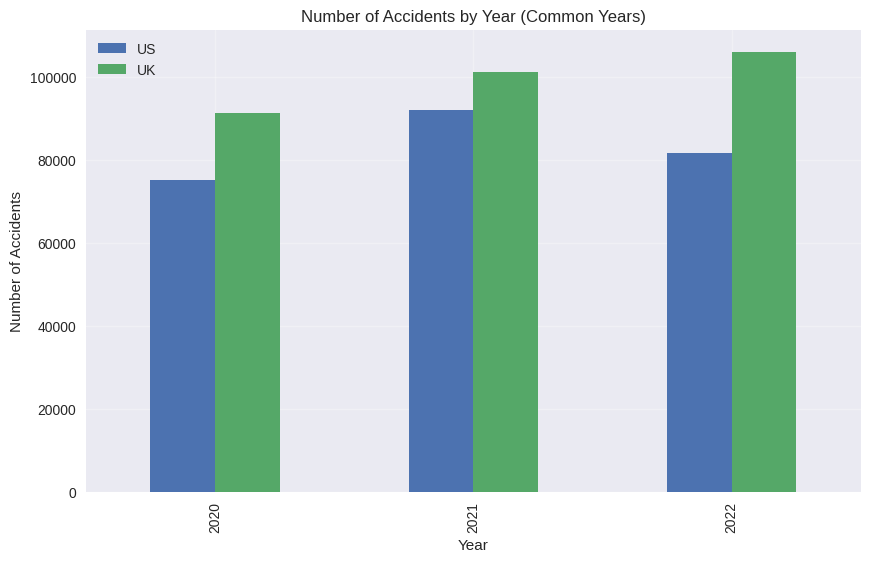

In [66]:
plt.style.use('seaborn-v0_8')

yearly = pd.DataFrame({
    'US': us_filtered['Year'].value_counts().sort_index(),
    'UK': uk_filtered['Year'].value_counts().sort_index()
})

yearly.plot(kind='bar', figsize=(10, 6))
plt.title('Number of Accidents by Year (Common Years)')
plt.ylabel('Number of Accidents')
plt.xlabel('Year')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

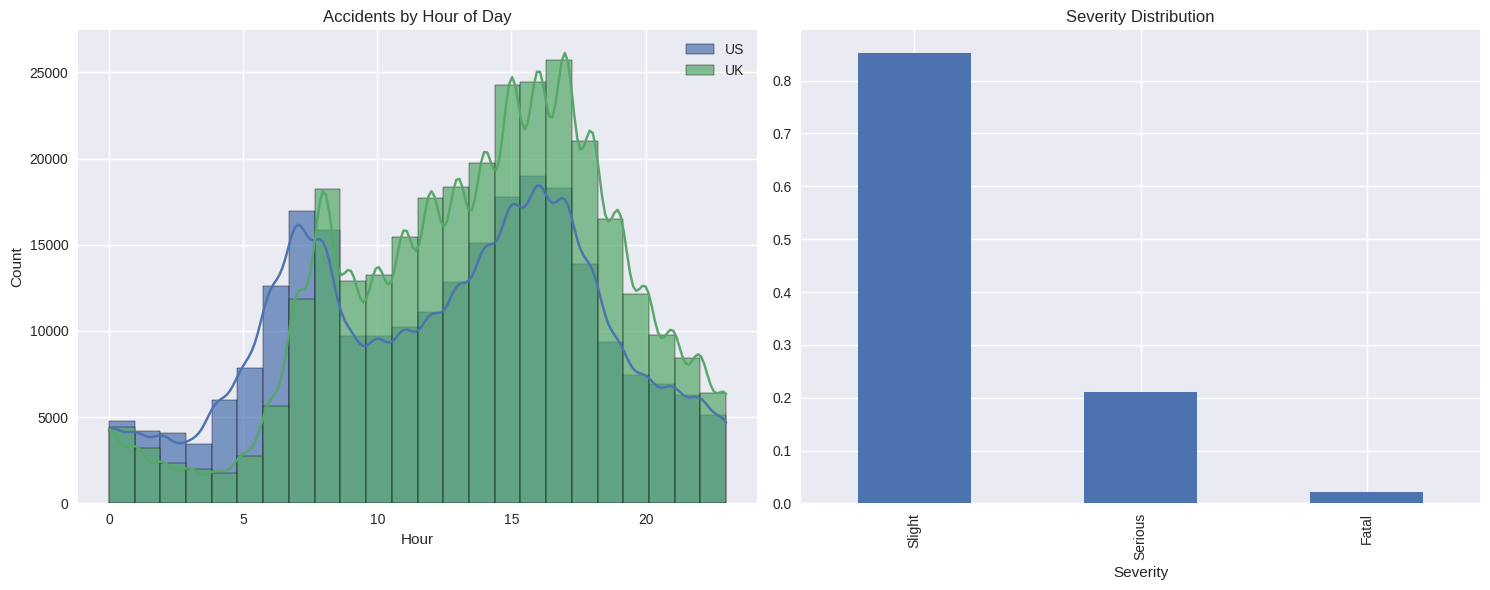

Summary:
Total US accidents (common years): 248,655
Total UK accidents (common years): 298,290


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Hourly distribution
sns.histplot(data=us_filtered, x='Hour', bins=24, kde=True, 
             label='US', alpha=0.7, ax=axes[0])
sns.histplot(data=uk_filtered, x='Hour', bins=24, kde=True, 
             label='UK', alpha=0.7, ax=axes[0])
axes[0].set_title('Accidents by Hour of Day')
axes[0].legend()

# Severity
us_sev = us_filtered['Severity'].value_counts(normalize=True)
uk_sev = uk_filtered['Severity'].map({1:'Fatal', 2:'Serious', 3:'Slight'}).value_counts(normalize=True)

us_sev.plot(kind='bar', ax=axes[1], label='US')
uk_sev.plot(kind='bar', ax=axes[1], label='UK')
axes[1].set_title('Severity Distribution')
plt.tight_layout()
plt.show()

print("Summary:")
print(f"Total US accidents (common years): {len(us_filtered):,}")
print(f"Total UK accidents (common years): {len(uk_filtered):,}")